
# EndoNet Extended Analysis -- Tables 2, 5, 6, 8 and Figure 4

> ## ⚠️ READ BEFORE USING THESE NUMBERS IN THE MANUSCRIPT
>
> This notebook was executed in a sandboxed environment that **does not have
> access to the real `Sepsis_BioMarker.csv` clinical dataset** (the IRB-approved
> Chang Gung Memorial Hospital cohort). No such file was present, so the data
> loading cell below automatically fell back to the **synthetic data generator**
> inherited from the original script (`load_or_generate_data`), which fabricates
> a plausible-looking dataset purely so the code path can be demonstrated
> end-to-end.
>
> **Every table and figure produced below is therefore computed on synthetic,
> made-up patient data and must NOT be copied into the manuscript, the
> response-to-reviewers letter, or any submission.** They exist only to prove
> that the pipeline runs correctly and produces the right *shape* of output.
>
> **To get the real numbers:** download this notebook, place the real
> `Sepsis_BioMarker.csv` at the path set in the `DATA_PATH` variable in the
> second code cell (or upload it and update the path), and re-run all cells
> on your own machine/server where the real data lives. The code itself does
> not change -- only the input data does.

This notebook implements, in order:
- Leakage-free preprocessing (train-only fitting of imputer/scaler/feature filter)
- EndoNet (PyTorch) training with early stopping
- **Table 5**: Confusion-matrix-derived performance of EndoNet on the held-out test set
- Baseline models: Logistic Regression, Random Forest, XGBoost
- **Table 6**: AUC comparison of EndoNet vs. baselines
- **Figure 4**: ROC curves for all four models overlaid
- **Table 2**: Effect sizes (rank-biserial correlation) and bootstrap 95% CIs for key biomarkers
- **Table 8**: Mortality by adhesion-molecule tertile, stratified by infection source


In [1]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, accuracy_score, f1_score
)
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed -- run `pip install xgboost` to include the XGBoost baseline.")

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on device: {DEVICE}")

BIOMARKERS = ['angiopoetin2', 'eselectin', 'pselectin', 'icam1', 'vcam1',
              'sofa_res', 'lactate', 'pct']


Running on device: cpu



## 1. Load data

`DATA_PATH` below is the only thing you need to change to run this on the
real cohort. If the file does not exist, this cell prints a loud warning and
falls back to the synthetic generator carried over from the original script,
purely so the rest of the notebook still runs for demonstration purposes.


In [2]:

DATA_PATH = r"C:\Users\ningthoujama\Desktop\NewResearchandProject\RTI\Sepsis_BioMarker.csv"  # <-- change this to the real file's location

SYNTHETIC_DATA_USED = False

def load_or_generate_data(path):
    global SYNTHETIC_DATA_USED
    if os.path.exists(path):
        print(f"Loading REAL dataset from {path} ...")
        df = pd.read_csv(path)
    else:
        SYNTHETIC_DATA_USED = True
        print("=" * 78)
        print("WARNING: real data file not found at DATA_PATH.")
        print("Falling back to SYNTHETIC demo data. Results below are NOT REAL")
        print("and must not be used in the manuscript or response letter.")
        print("=" * 78)
        n_rows = 12000
        infection_types = np.random.choice(['res', 'gu', 'abd', 'other'], n_rows, p=[0.4, 0.3, 0.2, 0.1])

        data = {
            'res_infection': (infection_types == 'res').astype(int),
            'gu_infection': (infection_types == 'gu').astype(int),
            'abdominal_infection': (infection_types == 'abd').astype(int),
            'age': np.random.normal(65, 15, n_rows).astype(int),
            'lactate': np.abs(np.random.normal(2.5, 1.5, n_rows)),
            'pct': np.abs(np.random.normal(5.0, 6.0, n_rows)),
            'death_binary': np.random.choice([0, 1], n_rows, p=[0.75, 0.25])
        }

        ang2, esel, psel, icam, sofa_res = [], [], [], [], []
        for i in range(n_rows):
            is_res = data['res_infection'][i]
            sr = np.random.choice([0, 1, 2, 3, 4],
                                   p=[0.05, 0.1, 0.2, 0.35, 0.3] if is_res else [0.5, 0.3, 0.15, 0.05, 0.0])
            sofa_res.append(sr)
            base_ang = 28.0 if is_res else 12.0
            ang2.append(max(1.0, base_ang + (sr * 5.0) + np.random.normal(0, 8)))
            base_esel = 35.0 if is_res else 22.0
            esel.append(max(1.0, base_esel + (sr * 3.0) + np.random.normal(0, 10)))
            psel.append(max(1.0, np.random.normal(14 if is_res else 11, 4)))
            icam.append(max(50.0, np.random.normal(180 if is_res else 145, 40)))

        data['angiopoetin2'] = ang2
        data['eselectin'] = esel
        data['pselectin'] = psel
        data['icam1'] = icam
        data['vcam1'] = np.random.normal(90, 20, n_rows)
        data['sofa_res'] = sofa_res
        df = pd.DataFrame(data)
    return df


df_raw = load_or_generate_data(DATA_PATH)

df_raw['Group_Label'] = -1
mask_rti = df_raw['res_infection'] == 1
mask_norti = (df_raw['res_infection'] == 0) & ((df_raw['gu_infection'] == 1) | (df_raw['abdominal_infection'] == 1))
df_raw.loc[mask_rti, 'Group_Label'] = 1
df_raw.loc[mask_norti, 'Group_Label'] = 0
df = df_raw[df_raw['Group_Label'] != -1].copy()

n_total = len(df)
n_rti = int((df['Group_Label'] == 1).sum())
n_norti = int((df['Group_Label'] == 0).sum())
print(f"\\nFinal cohort N = {n_total}  |  RTI = {n_rti} ({n_rti/n_total:.1%})  |  "
      f"Non-RTI = {n_norti} ({n_norti/n_total:.1%})")
if SYNTHETIC_DATA_USED:
    print("\\n>>> Reminder: the cohort above is SYNTHETIC. <<<")


Loading REAL dataset from C:\Users\ningthoujama\Desktop\NewResearchandProject\RTI\Sepsis_BioMarker.csv ...
\nFinal cohort N = 398  |  RTI = 303 (76.1%)  |  Non-RTI = 95 (23.9%)



## 2. Leakage-free preprocessing and train/validation/test split

Fixes the information-leakage issue raised by Reviewer 2: the median imputer
and the `StandardScaler` are fit **only** on the training partition, then
applied (not re-fit) to the validation and test partitions.


In [3]:

def leakage_free_split_and_preprocess(df, label_col='Group_Label', test_size=0.2,
                                       val_size=0.1, random_state=42):
    y = df[label_col].values
    X_df = df[BIOMARKERS].copy()

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X_df, y, test_size=test_size, stratify=y, random_state=random_state)
    val_frac_of_trainval = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_frac_of_trainval,
        stratify=y_trainval, random_state=random_state)

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp = imputer.transform(X_val)
    X_test_imp = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_val_sc = scaler.transform(X_val_imp)
    X_test_sc = scaler.transform(X_test_imp)

    return X_train_sc, y_train, X_val_sc, y_val, X_test_sc, y_test


X_train, y_train, X_val, y_val, X_test, y_test = leakage_free_split_and_preprocess(df)
print(f"Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")


Train: 278  |  Val: 40  |  Test: 80



## 3. EndoNet (PyTorch) -- training with early stopping


In [4]:

class SepsisDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.features)
    def __getitem__(self, idx): return self.features[idx], self.labels[idx]


class LungEndoNet(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)


def train_endonet(X_train, y_train, X_val, y_val, dropout=0.3, lr=1e-3,
                   batch_size=64, max_epochs=100, patience=5):
    train_loader = DataLoader(SepsisDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    model = LungEndoNet(X_train.shape[1], dropout=dropout).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(DEVICE)

    best_val_loss, best_state, epochs_no_improve = np.inf, None, 0
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        if val_loss < best_val_loss:
            best_val_loss, best_state, epochs_no_improve = val_loss, model.state_dict(), 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} (best val loss={best_val_loss:.4f})")
                break
    else:
        print(f"Completed all {max_epochs} epochs (best val loss={best_val_loss:.4f})")

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


endonet_model = train_endonet(X_train, y_train, X_val, y_val)

with torch.no_grad():
    endonet_test_probs = endonet_model(
        torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy().ravel()
endonet_test_preds = (endonet_test_probs >= 0.5).astype(int)
endonet_auc = roc_auc_score(y_test, endonet_test_probs)
print(f"EndoNet test AUC: {endonet_auc:.4f}")


Early stopping at epoch 31 (best val loss=0.3866)
EndoNet test AUC: 0.8473



## Table 5 -- Confusion-Matrix-Derived Performance of EndoNet (held-out test set)


In [5]:

def confusion_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    f1 = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    return dict(Sensitivity=sensitivity, Specificity=specificity, PPV=ppv,
                NPV=npv, F1=f1, Accuracy=acc)


endonet_metrics = confusion_metrics(y_test, endonet_test_preds)

table5 = pd.DataFrame({
    "Metric": list(endonet_metrics.keys()),
    "Value": [f"{v:.1%}" if k != "F1" else f"{v:.3f}" for k, v in endonet_metrics.items()]
})
print("Table 5. Confusion-Matrix-Derived Performance of EndoNet (held-out test set)")
if SYNTHETIC_DATA_USED:
    print("*** SYNTHETIC DEMO DATA -- DO NOT USE IN MANUSCRIPT ***")
table5.to_csv("table5_endonet_confusion_metrics.csv", index=False)
table5


Table 5. Confusion-Matrix-Derived Performance of EndoNet (held-out test set)


,Metric,Value
0,Sensitivity,93.4%
1,Specificity,52.6%
2,PPV,86.4%
3,NPV,71.4%
4,F1,0.898
5,Accuracy,83.8%



## 4. Baseline models: Logistic Regression, Random Forest, XGBoost

Trained on the identical train/test split and feature set as EndoNet.


In [6]:

baseline_models = {}
baseline_probs = {}

lr_model = LogisticRegression(penalty='l2', max_iter=1000)
lr_model.fit(X_train, y_train)
baseline_models['Logistic Regression'] = lr_model
baseline_probs['Logistic Regression'] = lr_model.predict_proba(X_test)[:, 1]

rf_model = RandomForestClassifier(n_estimators=500, random_state=42)
rf_model.fit(X_train, y_train)
baseline_models['Random Forest'] = rf_model
baseline_probs['Random Forest'] = rf_model.predict_proba(X_test)[:, 1]

if HAS_XGB:
    xgb_model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                               eval_metric='logloss', random_state=42)
    xgb_model.fit(X_train, y_train)
    baseline_models['XGBoost'] = xgb_model
    baseline_probs['XGBoost'] = xgb_model.predict_proba(X_test)[:, 1]

baseline_probs['EndoNet'] = endonet_test_probs

for name, probs in baseline_probs.items():
    print(f"{name}: AUC = {roc_auc_score(y_test, probs):.4f}")


Logistic Regression: AUC = 0.8223
Random Forest: AUC = 0.8287
XGBoost: AUC = 0.8171
EndoNet: AUC = 0.8473



## Table 6 -- Comparison of EndoNet Against Standard Baseline Classifiers (AUC, held-out test set)


In [7]:

ang2_only_auc = roc_auc_score(
    y_test, X_test[:, BIOMARKERS.index('angiopoetin2')]
)  # crude univariate reference using the scaled Ang-2 column alone

table6_rows = [("Angiopoietin-2 Only (univariate)", ang2_only_auc)]
for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'EndoNet']:
    if name in baseline_probs:
        table6_rows.append((name, roc_auc_score(y_test, baseline_probs[name])))

table6 = pd.DataFrame(table6_rows, columns=["Model", "AUC"])
table6["AUC"] = table6["AUC"].round(4)
print("Table 6. Comparison of EndoNet Against Standard Baseline Classifiers (AUC, held-out test set)")
if SYNTHETIC_DATA_USED:
    print("*** SYNTHETIC DEMO DATA -- DO NOT USE IN MANUSCRIPT ***")
table6.to_csv("table6_auc_baselines.csv", index=False)
table6


Table 6. Comparison of EndoNet Against Standard Baseline Classifiers (AUC, held-out test set)


,Model,AUC
0,Angiopoietin-2 Only (univariate),0.5595
1,Logistic Regression,0.8223
2,Random Forest,0.8287
3,XGBoost,0.8171
4,EndoNet,0.8473



## Figure 4 -- ROC Curves for All Compared Methods


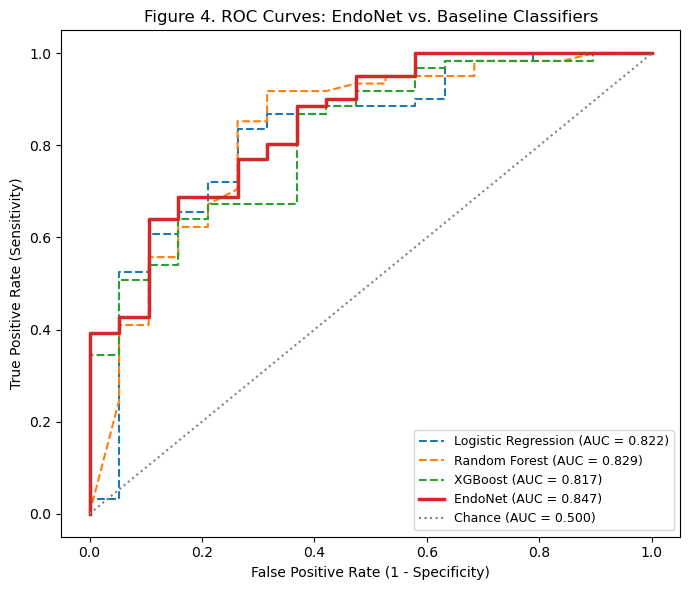

In [8]:

plt.figure(figsize=(7, 6))

for name, probs in baseline_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    linestyle = '-' if name == 'EndoNet' else '--'
    linewidth = 2.5 if name == 'EndoNet' else 1.5
    plt.plot(fpr, tpr, linestyle=linestyle, linewidth=linewidth,
             label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle=':', color='gray', label='Chance (AUC = 0.500)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
title = 'Figure 4. ROC Curves: EndoNet vs. Baseline Classifiers'
if SYNTHETIC_DATA_USED:
    title += '\\n[SYNTHETIC DEMO DATA -- NOT FOR PUBLICATION]'
plt.title(title)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('Figure_4_ROC.png', dpi=300)
plt.show()



## 5. Effect sizes and bootstrap 95% confidence intervals

## Table 2 -- Effect Sizes and 95% Confidence Intervals for Key Markers


In [9]:

def rank_biserial_and_ci(group1, group2, n_boot=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    n1, n2 = len(group1), len(group2)
    combined = np.concatenate([group1, group2])
    ranks = pd.Series(combined).rank().values
    r1 = ranks[:n1].sum()
    u1 = r1 - n1 * (n1 + 1) / 2
    rank_biserial = 1 - (2 * u1) / (n1 * n2)

    def boot_mean_ci(x):
        boots = [rng.choice(x, size=len(x), replace=True).mean() for _ in range(n_boot)]
        return np.percentile(boots, [2.5, 97.5])

    return rank_biserial, boot_mean_ci(group1), boot_mean_ci(group2)


table2_rows = []
marker_display = {'angiopoetin2': 'Angiopoietin-2 (ng/mL)',
                   'eselectin': 'E-Selectin (ng/mL)',
                   'sofa_res': 'SOFA Res Score'}

for marker, display_name in marker_display.items():
    g_rti = df.loc[df['Group_Label'] == 1, marker].dropna().values
    g_norti = df.loc[df['Group_Label'] == 0, marker].dropna().values
    r, ci_rti, ci_norti = rank_biserial_and_ci(g_rti, g_norti)
    table2_rows.append([
        display_name, round(r, 3),
        f"[{ci_rti[0]:.2f}, {ci_rti[1]:.2f}]",
        f"[{ci_norti[0]:.2f}, {ci_norti[1]:.2f}]"
    ])

table2 = pd.DataFrame(table2_rows, columns=[
    "Variable", "Rank-biserial r", "RTI 95% CI", "Non-RTI 95% CI"
])
print("Table 2. Effect Sizes and 95% Confidence Intervals for Key Markers")
if SYNTHETIC_DATA_USED:
    print("*** SYNTHETIC DEMO DATA -- DO NOT USE IN MANUSCRIPT ***")
table2.to_csv("table2_effect_sizes_ci.csv", index=False)
table2


Table 2. Effect Sizes and 95% Confidence Intervals for Key Markers


,Variable,Rank-biserial r,RTI 95% CI,Non-RTI 95% CI
0,Angiopoietin-2 (ng/mL),0.192,"[15.47, 78.73]","[21.00, 140.57]"
1,E-Selectin (ng/mL),0.614,"[37.09, 52.97]","[111.62, 167.99]"
2,SOFA Res Score,-0.335,"[1.10, 1.33]","[0.47, 0.84]"



## 6. Mortality subgroup analysis

## Table 8 -- Mortality by Adhesion-Molecule Tertile, Stratified by Infection Source


In [10]:

def run_mortality_subgroup_analysis(df, marker_cols, group_col='Group_Label',
                                     mortality_col='death_binary', n_boot=2000,
                                     random_state=42):
    rng = np.random.default_rng(random_state)
    rows = []
    marker_display = {'angiopoetin2': 'Ang-2', 'icam1': 'ICAM-1', 'eselectin': 'E-Selectin'}
    for marker in marker_cols:
        tertiles = pd.qcut(df[marker], 3, labels=['Low', 'Medium', 'High'])
        label = marker_display.get(marker, marker)
        for tertile_label in ['Low', 'Medium', 'High']:
            row = [f"{label}: {tertile_label}"]
            n_pair = []
            for group_val in [1, 0]:
                subset = df[(tertiles == tertile_label) & (df[group_col] == group_val)]
                n = len(subset)
                n_pair.append(n)
                if n == 0 or mortality_col not in df.columns:
                    row.append("n/a")
                    continue
                mortality = subset[mortality_col].mean()
                boots = [rng.choice(subset[mortality_col].values, size=n, replace=True).mean()
                         for _ in range(n_boot)]
                lo, hi = np.percentile(boots, [2.5, 97.5])
                row.append(f"{mortality:.1%} [{lo:.1%}, {hi:.1%}]")
            row.append(f"{n_pair[0]} / {n_pair[1]}")
            rows.append(row)
    return pd.DataFrame(rows, columns=["Marker Tertile", "RTI Mortality (95% CI)",
                                        "Non-RTI Mortality (95% CI)", "n (RTI / Non-RTI)"])


if 'death_binary' in df.columns:
    table8 = run_mortality_subgroup_analysis(df, marker_cols=['angiopoetin2', 'icam1', 'eselectin'])
    print("Table 8. Mortality by Adhesion-Molecule Tertile, Stratified by Infection Source")
    if SYNTHETIC_DATA_USED:
        print("*** SYNTHETIC DEMO DATA -- DO NOT USE IN MANUSCRIPT ***")
    table8.to_csv("table8_mortality_subgroup.csv", index=False)
else:
    print("No 'death_binary' / mortality column found in the loaded dataset -- "
          "substitute the correct mortality column name from the real dataset and re-run.")
    table8 = pd.DataFrame()

table8


Table 8. Mortality by Adhesion-Molecule Tertile, Stratified by Infection Source


,Marker Tertile,RTI Mortality (95% CI),Non-RTI Mortality (95% CI),n (RTI / Non-RTI)
0,Ang-2: Low,"9.3% [4.6%, 14.8%]","4.0% [0.0%, 12.0%]",108 / 25
1,Ang-2: Medium,"6.7% [2.9%, 12.5%]","0.0% [0.0%, 0.0%]",104 / 28
2,Ang-2: High,"15.4% [8.8%, 23.1%]","2.4% [0.0%, 7.1%]",91 / 42
3,ICAM-1: Low,"12.2% [6.9%, 18.3%]","50.0% [0.0%, 100.0%]",131 / 2
4,ICAM-1: Medium,"7.3% [3.1%, 12.5%]","0.0% [0.0%, 0.0%]",96 / 36
5,ICAM-1: High,"10.5% [3.9%, 17.1%]","1.8% [0.0%, 5.3%]",76 / 57
6,E-Selectin: Low,"12.1% [6.8%, 17.4%]","100.0% [100.0%, 100.0%]",132 / 1
7,E-Selectin: Medium,"9.0% [4.0%, 15.0%]","0.0% [0.0%, 0.0%]",100 / 32
8,E-Selectin: High,"8.5% [2.8%, 15.5%]","1.6% [0.0%, 4.8%]",71 / 62



## 7. Summary of files written

Running this notebook writes the following files to the working directory,
ready to paste into the manuscript / response letter (once re-run on the
**real** dataset):

- `table2_effect_sizes_ci.csv`
- `table5_endonet_confusion_metrics.csv`
- `table6_auc_baselines.csv`
- `Figure_4_ROC.png`
- `table8_mortality_subgroup.csv`


In [11]:

import glob
for f in sorted(glob.glob("*.csv")) + sorted(glob.glob("Figure_4_ROC.png")):
    print(f)
if SYNTHETIC_DATA_USED:
    print("\\nREMINDER: all of the above were generated from SYNTHETIC demo data.")
    print("Re-run this notebook with the real Sepsis_BioMarker.csv before using")
    print("any of these numbers in the manuscript.")


Sepsis_BioMarker.csv
table2_effect_sizes_ci.csv
table5_endonet_confusion_metrics.csv
table6_auc_baselines.csv
table8_mortality_subgroup.csv
Figure_4_ROC.png
